# First, let us set up a few dependencies

Don't forget to switch to a GPU-enabled colab runtime!

```
Runtime -> Change Runtime Type -> GPU
```

# Setup

## Create an account on Hugging Face

If you have not done so already, you need to [create an account on Hugging Face](https://huggingface.co/join).

## Request access to the SAM3 model

If you have not already you need to request access to the SAM3 model from facebook.

Check [the model page](https://huggingface.co/facebook/sam3) to request access and confirm you're approved. If you request access it can take a few minutes for your access to be approved.

## Set up your Hugging Face Access Token

Go to [the Hugging Face tokens settings](https://huggingface.co/settings/tokens) and click `Create new token`. In the settings for the token you can choose `Fine Grained` and make sure that the box labeled `Read access to contents of all public gated repos you can access` is checked. Once you have created your token, click `Copy` button to copy it to the clipboard. The click on the `+ Add new secret` link. Toggle the `Notebook access` to ON, under Name enter `HF_TOKEN` and in the Value field paste the token that you copied.

**Note** if you get to the bottom where we run the SAM3 model and it says that you do not have access to the model, you may need to `Disconnect` and `Reconnect` by clicking on the down arrow next to Ram and Disk on the top right and selecting `Disconnect and delete Runtime` and then confirm. And then reconnect.

# Preparing your Data and Google Drive

You can run through executing the following cells in order. These will unzip your data, mount your Google Drive, as well set a few variables that we will use later.

In [2]:
from huggingface_hub import login
# If you see a UserWarning about HF_TOKEN not existing in Colab secrets,
# please ensure you have set up your Hugging Face Access Token as a Colab secret
# named 'HF_TOKEN' as described in the "Set up your Hugging Face Access Token" section.
# Then, restart your Colab runtime for the secret to take effect.
login()

In [3]:
using_colab = True

In [4]:
if using_colab:
    import sys, os, pathlib, re
    import torch, torchvision

    print("PyTorch version:", torch.__version__)
    print("Torchvision version:", torchvision.__version__)
    print("CUDA is available:", torch.cuda.is_available())

    !{sys.executable} -m pip install -q decord ultralytics

    repo_dir = "/content/sam3"
    if os.path.exists(repo_dir):
        !rm -rf {repo_dir}
    !git clone -q https://github.com/facebookresearch/sam3.git {repo_dir}

    pyproject = pathlib.Path(repo_dir) / "pyproject.toml"
    text = pyproject.read_text()
    text = re.sub(r'"numpy==[^"]+",?', "", text)
    pyproject.write_text(text)

    %cd {repo_dir}
    !{sys.executable} -m pip install -q -e .
    %cd /content

    if "sam3" in sys.modules:
        del sys.modules["sam3"]
    if repo_dir not in sys.path:
        sys.path.insert(0, repo_dir)

PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
CUDA is available: True
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 66.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sam3 0.1.0 requires numpy<2,>=1.26, but you have numpy 2.4.5 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.5 which is incompatible.
/content/sam3
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for sam3 (pyproject.toml) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 r

In [5]:
import shutil
from pathlib import Path

import yaml
import numpy as np
from PIL import Image
from tqdm import tqdm
from glob import glob
import matplotlib.pyplot as plt

from ultralytics import YOLO

The following mounts your google drive to this notebook. You might have to change the path to fit with your dataset folder inside your drive. You will need to accept to give access to Google Drive from this notebook (check all the boxes).

In [6]:
# Mount the drive
from google.colab import drive
drive.mount('/content/drive/')
DRIVE_PATH = "/content/drive/MyDrive/" #update the path with the location of zipfile

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# Unzip the dataset
DATASET_DIR_NAME = "duckietown_dataset"
DATASET_ZIP_NAME = f"{DATASET_DIR_NAME}.zip"
DATASET_DIR_PATH = os.path.join("/content", DATASET_DIR_NAME)
TRAIN_DIR = "train"
VALIDATION_DIR = "val"
IMAGES_DIR = "images"
LABELS_DIR = "labels"


def show_info(base_path: str):
  for l1 in [TRAIN_DIR, VALIDATION_DIR]:
    for l2 in [IMAGES_DIR, LABELS_DIR]:
      p = os.path.join(base_path, l1, l2)
      print(f"#Files in {l1}/{l2}: {len(os.listdir(p))}")


def unzip_dataset():
  # check zipped file
  zip_path = os.path.join(DRIVE_PATH, DATASET_ZIP_NAME)
  assert os.path.exists(zip_path), f"No zipped dataset found at {zip_path}! Abort!"

  # unzip the data
  print("Unpacking zipped data...")
  shutil.unpack_archive(zip_path, DATASET_DIR_PATH)
  print(f"Zipped dataset unpacked to {DATASET_DIR_PATH}")

  # show some info
  show_info(DATASET_DIR_PATH)


unzip_dataset()

Unpacking zipped data...
Zipped dataset unpacked to /content/duckietown_dataset
#Files in train/images: 89
#Files in train/labels: 0
#Files in val/images: 23
#Files in val/labels: 0


Let's setup a few directory variables that we will use later.

In [8]:
DATASET_DIR = Path(DATASET_DIR_PATH)
TRAIN_DIR = DATASET_DIR / "train"
VAL_DIR = DATASET_DIR / "val"
CLASSES_YAML = DATASET_DIR / "classes.yaml"

Let's create the config file we need for training our duckie detector as well.

In [9]:
%%writefile /content/duckietown_dataset/classes.yaml

# train and val data as 1) directory: path/images/, 2) file: path/images.txt, or 3) list: [path1/images/, path2/images/]
train:  /content/duckietown_dataset/train
val:    /content/duckietown_dataset/val

# class names
names:
  0: 'yellow rubber duck' # you can try adding more classes if you'd like

Overwriting /content/duckietown_dataset/classes.yaml


# Run Auto Labelling using [SAM3](https://ai.meta.com/sam3/)

In [10]:
from sam3.model_builder import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor

/content/sam3/sam3/model/model_misc.py:70: UserWarning: Flash Attention is disabled as it requires a GPU with Ampere (8.0) CUDA capability.
  OLD_GPU, USE_FLASH_ATTN, MATH_KERNEL_ON = get_sdpa_settings()


Define some functions that will be useful later

In [11]:
def load_classes(classes_yaml):
  with open(classes_yaml, "r") as f:
    cfg = yaml.safe_load(f)
  items = sorted(cfg["names"].items(), key=lambda kv: int(kv[0]))
  return [name for _, name in items]


def xyxy_to_yolo_line(bbox, w, h, class_id):
  x1, y1, x2, y2 = bbox
  cx = (x1 + x2) / 2.0 / w
  cy = (y1 + y2) / 2.0 / h
  bw = (x2 - x1) / w
  bh = (y2 - y1) / h
  return f"{class_id} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}"


class Sam3AutoLabel:
  def __init__(
    self,
    train_dir,
    val_dir,
    dataset_dir,
    classes_yaml,
    bpe_path="/content/sam3/assets/bpe_simple_vocab_16e6.txt.gz",
    confidence_threshold=0.3,
    device=None,
  ):
    self.train_dir = train_dir
    self.val_dir = val_dir
    self.dataset_dir = dataset_dir
    self.classes_yaml = classes_yaml

    if device is None:
      device = "cuda" if torch.cuda.is_available() else "cpu"
    self.device = device

    self.classes = load_classes(self.classes_yaml)

    self.model = build_sam3_image_model(bpe_path=str(bpe_path))
    self.model.to(device)
    self.model.eval()

    self.processor = Sam3Processor(
      self.model,
      confidence_threshold=confidence_threshold,
      device=device,
    )

  def _detect(self, img_path: Path):
    image = Image.open(img_path).convert("RGB")
    w, h = image.size

    with torch.no_grad():
      if self.device == "cuda":
        ctx = torch.autocast("cuda", dtype=torch.bfloat16)
      else:
        from contextlib import nullcontext
        ctx = nullcontext()

      with ctx:
        st = self.processor.set_image(image)

        dets = []
        for class_id, prompt in enumerate(self.classes):
          out = self.processor.set_text_prompt(state=st, prompt=prompt)
          boxes = out.get("boxes")
          scores = out.get("scores")
          if boxes is None or scores is None:
            continue

          for b, s in zip(boxes, scores):
            s = float(s)
            if s < self.processor.confidence_threshold:
              continue
            dets.append(
              {
                  "bbox": b.tolist(),
                  "score": s,
                  "class_id": int(class_id),
              }
            )

    return dets, (w, h)

  def _label_split(self, split: str):
    split_dir = self.train_dir if split == "train" else self.val_dir
    img_dir = split_dir / "images"
    lbl_dir = split_dir / "labels"

    img_paths = []
    for ext in ("*.jpg", "*.jpeg", "*.png"):
      img_paths.extend(img_dir.rglob(ext))

    for img_path in tqdm(img_paths, desc=f"Labeling {split}"):
      dets, (w, h) = self._detect(img_path)

      yolo_lines = []
      for d in dets:
        bbox = d["bbox"]
        class_id = d["class_id"]

        yolo_lines.append(
          xyxy_to_yolo_line(bbox, w, h, class_id)
        )

      label_path = lbl_dir / f"{img_path.stem}.txt"
      if yolo_lines:
        label_path.write_text("\n".join(yolo_lines))
      else:
        if label_path.exists():
          label_path.unlink()

  def run(self):
    self._label_split("train")
    self._label_split("val")

The following code will be useful for visualizing some outputs after the autolabeling part is complete:

In [12]:
def visualize_labels_for_image(img_path: Path, labels_dir: Path, class_names=None, save_to: Path | None = None):
  img_path = Path(img_path)
  label_path = labels_dir / (img_path.stem + ".txt")

  if not label_path.exists():
    return

  image = Image.open(img_path).convert("RGB")
  w, h = image.size

  with open(label_path, "r") as f:
    lines = [ln.strip() for ln in f.readlines() if ln.strip()]

  fig, ax = plt.subplots(figsize=(6, 6))
  ax.imshow(image)
  ax.axis("off")

  for line in lines:
    parts = line.split()
    if len(parts) != 5:
      continue
    class_id = int(parts[0])
    cx, cy, bw, bh = map(float, parts[1:])

    box_w = bw * w
    box_h = bh * h
    x1 = cx * w - box_w / 2
    y1 = cy * h - box_h / 2

    rect = plt.Rectangle(
      (x1, y1),
      box_w,
      box_h,
      fill=False,
      linewidth=2,
    )
    ax.add_patch(rect)

    label = str(class_id)
    if class_names is not None and 0 <= class_id < len(class_names):
      label = class_names[class_id]

    ax.text(
      x1,
      y1 - 2,
      label,
      fontsize=10,
      bbox=dict(facecolor="black", alpha=0.5),
      color="white",
    )

  if save_to is not None:
    save_to = Path(save_to)
    save_to.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_to, bbox_inches="tight", pad_inches=0)
    plt.close(fig)
  else:
    plt.show()

We are ready to run SAM3 on your dataset!

In [13]:
import os

# Ensure the assets directory exists where the BPE vocabulary file is expected
# repo_dir is defined in previous cells as '/content/sam3'
assets_dir = os.path.join(repo_dir, "assets")
os.makedirs(assets_dir, exist_ok=True)

# The bpe_path argument explicitly points to the location of the uploaded file.
autolabel = Sam3AutoLabel(
    train_dir=TRAIN_DIR,
    val_dir=VAL_DIR,
    dataset_dir=DATASET_DIR,
    classes_yaml=CLASSES_YAML,
    confidence_threshold=0.3,
    bpe_path=os.path.join(assets_dir, "bpe_simple_vocab_16e6.txt.gz"),
)

autolabel.run()

Labeling val: 100%|██████████| 23/23 [01:19<00:00,  3.44s/it]


Lets visualize some of the predicted detections

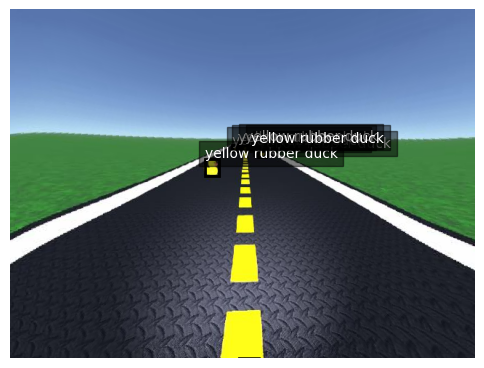

In [14]:
train_images = TRAIN_DIR / "images"
train_labels = TRAIN_DIR / "labels"

label = next(train_labels.glob("*.txt"))

img_name = label.stem + ".png"
img = train_images / img_name

if not img.exists():
    raise FileNotFoundError(f"Image not found for label {label.name}")

visualize_labels_for_image(
    img_path=img,
    labels_dir=train_labels,
    class_names=load_classes(CLASSES_YAML),
)

# And we're ready to train! This step will take about 5 minutes.

Notice that we're only training for 10 epochs. That's probably not enough!

You can modify the config file in `classes.yaml` to update the class lists. If you have done so previously for the autolabelling or you can keep it as is.

In [15]:
# training from scratch - you can play around with different yolo models if you wish
model = YOLO("yolo11n.yaml")

runs_root = DATASET_DIR / "runs"
run_name = "duckietown_detection"

model.train(
    data=str(CLASSES_YAML),
    epochs=10,
    imgsz=(480,640),
    batch=16,
    workers=2,
    project=str(runs_root),
    name=run_name,
)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/duckietown_dataset/classes.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=(480, 640), int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.yaml, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=duckietown_detection, nbs=64, nms=False, opset=None, optimize=False, optimizer=aut

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c607c07b980>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

You can check the `duckietown_dataset/runs/<run_name>` by clicking the `folder` icon on the left to see visuals of the confusion matrix, precision/recall/ROC plots, and some sample visualizations (similar to what is shown in the training jupyter notebook).

## Export your best model to ONNX

In [16]:
all_exps = os.listdir(f"{DATASET_DIR}/runs")
latest_exp_index = np.argmax(all_exps)
latest_exp = all_exps[latest_exp_index]
print(f"Latest exp is {latest_exp}")

Latest exp is duckietown_detection


In [17]:
run_dir = DATASET_DIR / "runs" / f"{latest_exp}" # you may need to update this based on you run_id
best = run_dir / "weights" / "best.pt"
model_path = DATASET_DIR / "weights" / "best.onnx"

if not best.exists():
    raise FileNotFoundError(f"Could not find best.pt at: {best}")

print(f"Using checkpoint: {best}")
model = YOLO(str(best))

onnx_tmp = run_dir / "weights" / "best.onnx"
print(f"Exporting ONNX to: {onnx_tmp}")

model.export(
    format="onnx",
    opset=18,
    imgsz=(480,640), # (height, width)
    simplify=True,
    dynamic=False,
    nms=True,
    half=True, # use FP16 - make sure device is set accordingly
    batch=1,
    optimize=False,
    device=0 # required for FP16 export - default to CPU if not specified
    )

model_path.parent.mkdir(parents=True, exist_ok=True)

model_path.write_bytes(onnx_tmp.read_bytes())

print(f"Copied ONNX model to: {model_path}")
print("Export finished successfully.")

Using checkpoint: /content/duckietown_dataset/runs/duckietown_detection/weights/best.pt
Exporting ONNX to: /content/duckietown_dataset/runs/duckietown_detection/weights/best.onnx
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs

PyTorch: starting from '/content/duckietown_dataset/runs/duckietown_detection/weights/best.pt' with input shape (1, 3, 480, 640) BCHW and output shape(s) (1, 300, 6) (5.2 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 317ms
Prepared 4 packages in 10.96s
Installed 4 packages in 448ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.26.0
 + on

# Download the model

Next, you must download your the `best.onnx` model!

You can do so by navigating to the directory `duckietown_Dataset/weights/` using the file folder on the left and then click the three dots and select `Download`. Then you should copy it from your `Downloads` folder to the `lx-object-detection/assets/` folder.



# Done!

We're done training! You can now close this tab and go back to the `Training` notebook